<a href="https://colab.research.google.com/github/samuabbade-data/Superstore-Sales-Performance-Dashboard-2015-2018-/blob/main/Sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Questions to answer**:

1. Which product sub-categories drive the majority of store revenue?
2. How does shipping method performance vary across geographic regions?
3. Which customer segment produces the highest business value?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#LOADING THE DATASET
store = pd.read_csv("Superstore Sales Dataset.csv")

In [ ]:
#GETTING INFO ABOUT IT
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
store.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [ ]:
#MISSING VALUES
store.isna().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
print(store)

      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
1          2  CA-2017-152156  08/11/2017  11/11/2017    Second Class   
2          3  CA-2017-138688  12/06/2017  16/06/2017    Second Class   
3          4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4          5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
...      ...             ...         ...         ...             ...   
9795    9796  CA-2017-125920  21/05/2017  28/05/2017  Standard Class   
9796    9797  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9797    9798  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9798    9799  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   
9799    9800  CA-2016-128608  12/01/2016  17/01/2016  Standard Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consumer  United 

In [ ]:
#CLEAN DUPLICATES AND MISSING VALUES

In [ ]:
#cleaning missing values
store["Postal Code"] = store["Postal Code"].fillna('Unknown')

In [ ]:
#visualize df columns
store.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [ ]:
# Automatically select and strip all text columns
text_cols = store.select_dtypes(include='object').columns
for col in text_cols:
    store[col] = store[col].str.strip()

In [ ]:
#convert datetime & extract year / month
store['Order Date'] = pd.to_datetime(store['Order Date'], dayfirst=True)
store['Ship Date'] = pd.to_datetime(store['Ship Date'], dayfirst=True)

In [ ]:
#Question 1: Product Revenue Leaders & Laggards

#Goal: Rank product categories and sub-categories by total sales volume and average item price to spot high vs. low revenue drivers.

In [ ]:
#Group by Category and Sub-Category for total and average sales
q1_store = store.groupby(['Category', 'Sub-Category']).agg(
    total_sales=('Sales', 'sum'),
    average_sales=('Sales', 'mean'),
    order_count=('Sales', 'count')
).reset_index()
q1_store = q1_store.sort_values(by='total_sales', ascending=False)
print(q1_store)


           Category Sub-Category  total_sales  average_sales  order_count
16       Technology       Phones  327782.4480     374.180877          876
1         Furniture       Chairs  322822.7310     531.833165          607
11  Office Supplies      Storage  219343.3920     263.633885          832
3         Furniture       Tables  202810.6280     645.893720          314
6   Office Supplies      Binders  200028.7850     134.067550         1492
15       Technology     Machines  189238.6310    1645.553313          115
13       Technology  Accessories  164186.7000     217.178175          756
14       Technology      Copiers  146248.0940    2215.880212           66
0         Furniture    Bookcases  113813.1987     503.598224          226
4   Office Supplies   Appliances  104618.4030     227.926804          459
2         Furniture  Furnishings   89212.0180      95.823865          931
10  Office Supplies        Paper   76828.3040      57.420257         1338
12  Office Supplies     Supplies   464

In [ ]:
#Question 2: Regional Performance & Shipping Modes

#Goal: Compare overall sales volume across geographical regions and shipping channels.
#Ship Mode, region

In [ ]:
q2_store = store.groupby(['Ship Mode', 'Region']).agg(
    total_sales=('Sales', 'sum'),
    average_sales=('Sales', 'mean'),
    order_count=('Order ID', 'count')
).reset_index()
q2_store = q2_store.sort_values(by='total_sales', ascending=False)

print(q2_store)

         Ship Mode   Region  total_sales  average_sales  order_count
13  Standard Class     East  400657.3110     244.303238         1640
15  Standard Class     West  397642.1825     215.992495         1841
12  Standard Class  Central  316877.9800     223.153507         1420
14  Standard Class    South  225653.8335     235.546799          958
11    Second Class     West  143765.6715     236.068426          609
3      First Class     West  128032.3505     252.529291          507
9     Second Class     East  115108.2580     220.937155          521
1      First Class     East  110436.6930     234.971687          470
8     Second Class  Central   97605.7134     218.357301          447
10    Second Class    South   93434.5365     287.490882          325
0      First Class  Central   58057.2978     198.826362          292
2      First Class    South   49045.9160     211.404810          232
5         Same Day     East   43316.4640     281.275740          154
7         Same Day     West   4077

In [ ]:
#Question 3: Customer Segment Analysis & AOV

#Goal: Calculate Average Order Value (AOV) and revenue contribution per customer segment.

In [ ]:
q3_store = store.groupby('Segment').agg(
    total_revenue=('Sales', 'sum'),
    avg_item_values=('Sales', 'mean'),
    total_orders=('Order ID', 'nunique'),
    total_items_sold=('Customer ID', 'count'),
).reset_index()

# Calculate true Average Order Value (AOV) per transaction
q3_store['avg_order_value'] = q3_store['total_revenue'] / q3_store['total_orders']


q3_store = q3_store.sort_values(by='total_revenue', ascending=False)

print(q3_store)

       Segment  total_revenue  avg_item_values  total_orders  \
0     Consumer   1.148061e+06       225.065777          2537   
1    Corporate   6.884941e+05       233.150720          1491   
2  Home Office   4.249822e+05       243.403309           894   

   total_items_sold  avg_order_value  
0              5101       452.526816  
1              2953       461.766650  
2              1746       475.371563  


In [ ]:
#format and round up numbers from table
q3_formatted = q3_store.copy()
q3_formatted['total_revenue'] = q3_formatted['total_revenue'].round(2)
q3_formatted['avg_item_values'] = q3_formatted['avg_item_values'].round(2)
q3_formatted['avg_order_value'] = q3_formatted['avg_order_value'].round(2)

print(q3_formatted)

       Segment  total_revenue  avg_item_values  total_orders  \
0     Consumer     1148060.53           225.07          2537   
1    Corporate      688494.07           233.15          1491   
2  Home Office      424982.18           243.40           894   

   total_items_sold  avg_order_value  
0              5101           452.53  
1              2953           461.77  
2              1746           475.37  


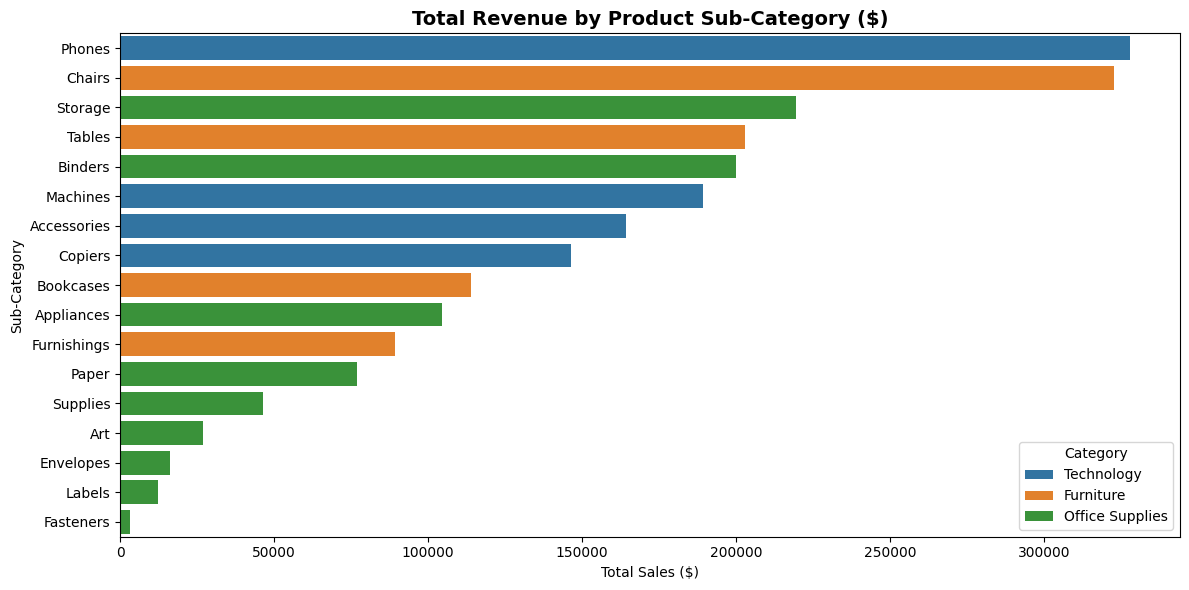

In [ ]:
#answering question 1
plt.figure(figsize=(12, 6))

# Horizontal barplot for readability of sub-category names
sns.barplot(
    data=q1_store,
    x='total_sales',
    y='Sub-Category',
    hue='Category',
    dodge=False
)

plt.title('Total Revenue by Product Sub-Category ($)', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

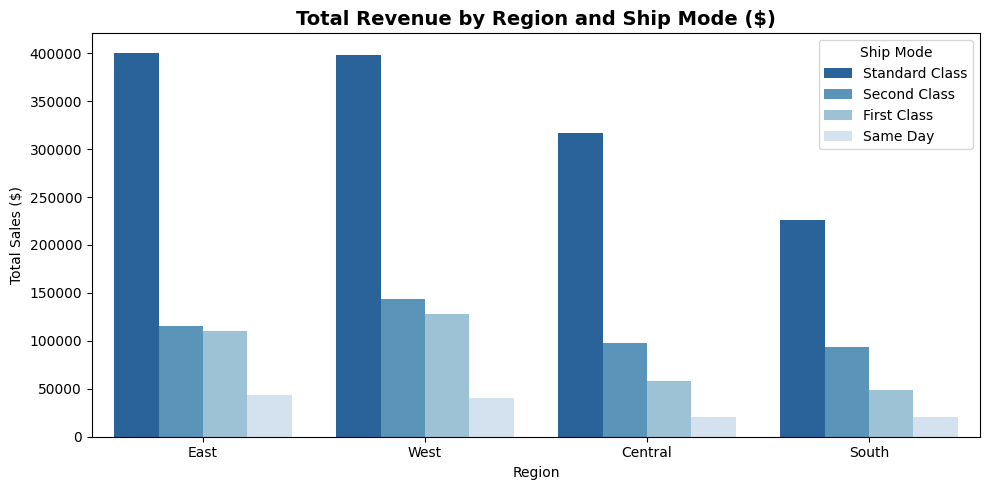

In [ ]:
#answering question 2

# Set figure size
plt.figure(figsize=(10, 5))

# Plot total revenue by Region split by Ship Mode
sns.barplot(
    data=q2_store,
    x='Region',
    y='total_sales',
    hue='Ship Mode',
    palette='Blues_r'
)

plt.title('Total Revenue by Region and Ship Mode ($)', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.legend(title='Ship Mode')
plt.tight_layout()
plt.show()

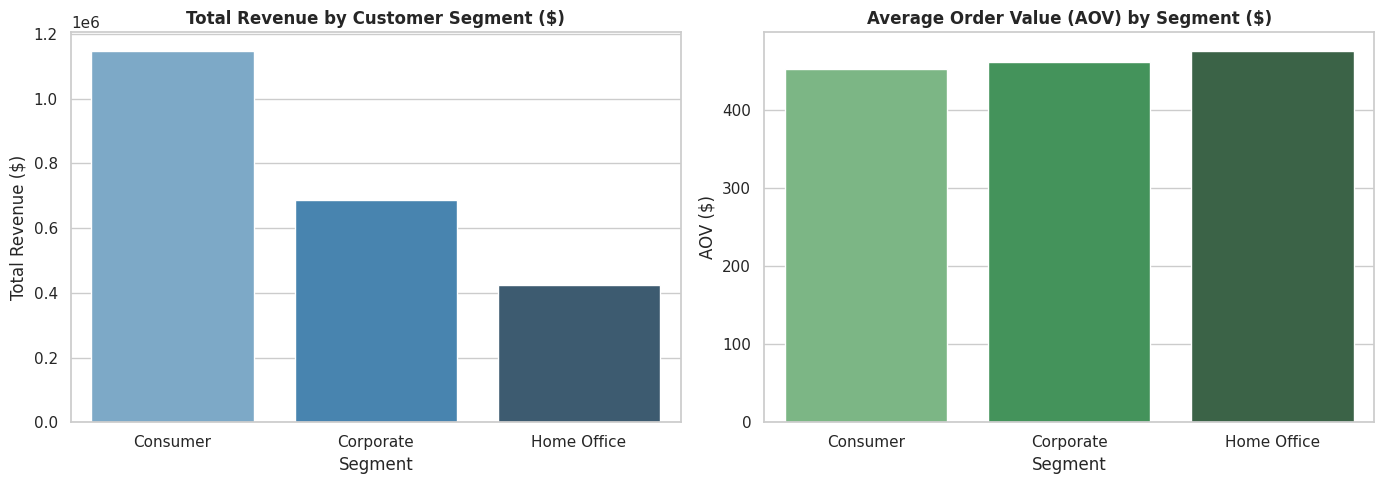

In [ ]:
#answering question 3
#visualization in seaborn
# Set chart style
sns.set_theme(style="whitegrid")

# Create side-by-side plots: Total Revenue vs. Average Order Value
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Total Revenue by Segment
sns.barplot(
    data=q3_store,
    x='Segment',
    y='total_revenue',
    hue='Segment',
    palette='Blues_d',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Total Revenue by Customer Segment ($)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total Revenue ($)')

# Chart 2: Average Order Value by Segment
sns.barplot(
    data=q3_store,
    x='Segment',
    y='avg_order_value',
    hue='Segment',
    palette='Greens_d',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Average Order Value (AOV) by Segment ($)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('AOV ($)')

plt.tight_layout()
plt.show()